## LangGraph là gì?

**LangGraph** là một framework dùng để xây dựng **LLM Agent có trạng thái (stateful agents)** dựa trên mô hình **đồ thị (graph)**. Thay vì chạy agent theo vòng lặp tuyến tính, LangGraph cho phép mô tả luồng suy luận và hành động bằng các **node** và **edge** rõ ràng.

## Điểm nổi bật của LangGraph
- Quản lý **state** xuyên suốt nhiều bước suy luận  
- Hỗ trợ **vòng lặp, rẽ nhánh và điều kiện dừng** một cách tường minh  
- Dễ dàng kết hợp **LLM, tools và memory**  
- Phù hợp với agent phức tạp, đa bước, cần kiểm soát luồng thực thi  

> Tóm lại: **LangGraph giúp xây dựng agent có logic rõ ràng, có trí nhớ và có khả năng kiểm soát luồng hoạt động**, thay vì chỉ là một vòng lặp gọi LLM đơn giản.


In [21]:
from unittest import result
from langgraph.graph import StateGraph, MessagesState, START, END

def mock_llm(state: MessagesState):
    return {"messages": [{"role": "ai", "content": "hello world"}]}

graph = StateGraph(MessagesState)
graph.add_node(mock_llm)
graph.add_edge(START, "mock_llm")
graph.add_edge("mock_llm", END)
graph = graph.compile()

result=graph.invoke({"messages": [{"role": "user", "content": "hi!"}]})

In [22]:
result["messages"][-1].content

'hello world'

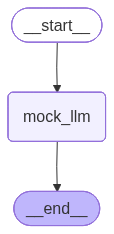

In [23]:
# show the image of the graph
import IPython
IPython.display.Image(graph.get_graph().draw_mermaid_png())


### Bài toán

Xây dựng chatbot chăm sóc khách hàng hỗ trợ xử lý yêu cầu hoàn tiền.

1. **Trò chuyện với khách hàng**  
   - Thu thập thông tin đơn hàng (mã đơn, lý do hoàn tiền, …)  
   - Ghi nhớ hội thoại để tránh hỏi lại (Memory)  
   - Human-in-the-loop: chờ khách hàng phản hồi khi thiếu thông tin  

2. **Kiểm tra trạng thái đơn hàng (Tool Call)**  
   - Gọi tool để kiểm tra:
     - Đơn hàng có tồn tại không  
     - Trạng thái giao hàng  
     - Có đủ điều kiện hoàn tiền hay không  

3. **Ra quyết định (LLM rẽ nhánh)**  
   - Nếu **không hợp lệ** → từ chối và giải thích lý do  
   - Nếu **hợp lệ** → đề xuất hoàn tiền  

4. **Xử lý kết quả**  
   - Không hợp lệ → thông báo kết quả cho khách hàng  
   - Hợp lệ → gọi tool gửi thông báo cho nhân viên xử lý giao dịch  
     (đồng thời thông báo cho khách hàng đang chờ phê duyệt)
![Graph Flow](./data/output.png)

In [24]:
# import library
from langgraph.graph import StateGraph, START, END

In [25]:
# create State
from typing_extensions import TypedDict
from typing import Optional
class Message(TypedDict):
    role: str
    content: str

class ChatState(TypedDict, total=False):
    messages: Optional[list[Message]]
    question: Optional[str]
    new_message: Optional[str]
    order_id: Optional[str]
    refund_reason: Optional[str]
    order_valid: Optional[bool]
    order_informations: Optional[dict]
    number_of_llm_rounds: int
    need_human_approval: bool
    error: Optional[bool]
    
    

In [26]:
# create core lllm
from langchain_openai import ChatOpenAI
from config import settings




In [27]:
import enum
class NODE_NAME(enum.Enum):
    EXTRACT_ORDER_ID_AND_REFUND_REASON = "extract_order_id_and_refund_reason"
    GENERATE_QUESTION = "generate_question"
    ASK_QUESTION = "ask_question"
    GET_ORDER_BY_ID = "get_order_by_id"
    REFUND_PRONOUNCE = "refund_pronounce"
    NO_ORDER_IN_SYSTEM = "no_order_in_system"


In [28]:
EXTRACT_ORDER_ID_AND_REFUND_REASON_PROMPT = """
Bạn là **nhân viên chăm sóc khách hàng**, nhiệm vụ của bạn là **xử lý yêu cầu hoàn tiền**.

Bạn sẽ được cung cấp **toàn bộ lịch sử hội thoại**, dưới dạng danh sách các tin nhắn.
- role = "user" → khách hàng
- role = "assistant" → nhân viên CSKH (bạn)

Nhiệm vụ của bạn:
1. Kiểm tra xem **khách hàng đã cung cấp mã đơn hàng (order_id) hay chưa**
2. Kiểm tra xem **khách hàng đã cung cấp lý do hoàn tiền (refund_reason) hay chưa**
3. Chỉ trích xuất thông tin **từ lời khách hàng (role=user)**  
4. **Không suy đoán**, không tự bịa thông tin

Nếu khách hàng:
- Đã cung cấp → trích xuất
- Chưa cung cấp → để giá trị là `null`

---

### Lịch sử hội thoại:
{chat_conversation}

---

### Yêu cầu output:
- Trả về **JSON hợp lệ**
- Không giải thích
- Không thêm text ngoài JSON

### Định dạng JSON:
```json
{{
  "order_id": string | null,
  "refund_reason": string | null
}}
"""

In [29]:
from pydantic import BaseModel

class ExtractOrderIdAndRefundReason(BaseModel):
    order_id: Optional[str]
    refund_reason: Optional[str]


In [30]:
# tool extract order_id and refund_reason from chat conversation
def extract_order_id_and_refund_reason(state: ChatState):
    try:
        print("Start extract order_id and refund_reason from chat conversation")
        messages=state.get("messages", [])
        if state.get("new_message", None):
            messages.append({"role": "user", "content": state.get("new_message")})
        prompt=EXTRACT_ORDER_ID_AND_REFUND_REASON_PROMPT.format(chat_conversation=messages)
        llm = ChatOpenAI(model=settings.LLM_CHAT_MODEL, 
                api_key=settings.LLM_API_KEY,
                base_url=settings.LLM_BASE_URL)
        llm=llm.with_structured_output(ExtractOrderIdAndRefundReason)
        response=llm.invoke(prompt)
    
        return {"order_id": response.order_id, "refund_reason": response.refund_reason, "messages": messages, "need_human_approval": False}
    except Exception as e:
        print(f"Error extracting order_id and refund_reason from chat conversation: {e}")
        return {"error": True}






In [31]:
GENERATE_QUESTION_PROMPT = """
Bạn là **nhân viên chăm sóc khách hàng**, nhiệm vụ của bạn là **xử lý yêu cầu hoàn tiền**.

Bạn sẽ được cung cấp **toàn bộ lịch sử hội thoại**, dưới dạng danh sách các tin nhắn:
- role = "user" → khách hàng
- role = "assistant" → nhân viên CSKH (bạn)

---

### Nhiệm vụ của bạn:
1. Xác định **những thông tin còn thiếu** để xử lý hoàn tiền:
   - `order_id` (mã đơn hàng)
   - `refund_reason` (lý do hoàn tiền)

2. **Chỉ hỏi lại những thông tin đang thiếu**
   - Nếu thiếu `order_id` → hỏi khách mã đơn hàng
   - Nếu thiếu `refund_reason` → hỏi lý do hoàn tiền
   - Nếu thiếu cả hai → hỏi cả hai trong **một câu lịch sự**

3. Không hỏi lại thông tin đã có
4. Không tự suy đoán hay bịa thông tin
5. Giữ giọng điệu **lịch sự – chuyên nghiệp – đúng vai CSKH**

---

### Lịch sử hội thoại:
{chat_conversation}

---

### Yêu cầu output:
- Trả về **một câu hỏi duy nhất**
- Không giải thích
- Không trả về JSON
- Không thêm text ngoài câu hỏi

---

### Ví dụ mong muốn:
- "Anh/chị vui lòng cung cấp mã đơn hàng để em kiểm tra giúp ạ."
- "Anh/chị có thể cho em biết lý do muốn hoàn tiền không ạ?"
- "Anh/chị vui lòng cho em xin mã đơn hàng và lý do hoàn tiền để em hỗ trợ tiếp nhé."
"""
class GenerateQuestion(BaseModel):
    question: str

def generate_question(state: ChatState):
    try:
        print("Start generating question")
        messages=state.get("messages", [])
        prompt=GENERATE_QUESTION_PROMPT.format(chat_conversation=messages)
        llm = ChatOpenAI(model=settings.LLM_CHAT_MODEL, 
                api_key=settings.LLM_API_KEY,
                base_url=settings.LLM_BASE_URL)
        llm=llm.with_structured_output(GenerateQuestion)
        response=llm.invoke(prompt)
        # append to messages
        messages.append({"role": "assistant", "content": response.question})
        return {"messages": messages, "question": response.question, "need_human_approval": True, "question":response.question}
    except Exception as e:
        print(f"Error generating question: {e}")
        return {"error": True}



In [32]:
from langgraph.types import interrupt
def ask_question(state: ChatState):
    print("Start asking question")
    question = state.get("question", None)
    if not question:
        print("No question to ask")
        return {"error": True}
    # human-in-the-loop
    human_answer = interrupt(question)
    print(f"After asking question: {human_answer}")
    if not human_answer:
        return {
            "error": True,
        }
    messages = state.get("messages", [])
    messages.append({"role": "user", "content": human_answer})
    return {"messages": messages, "question": None}


In [33]:
def get_order_by_id(state: ChatState):
    print("Start getting order by id")
    import json
    file_path = "data/order.json"
    if not state.get("order_id", None):
        return {
            "error": True,
        }
    order_id = state.get("order_id", None)
    with open(file_path, "r", encoding="utf-8") as f:
        orders = json.load(f)

    order = next(
        (o for o in orders if o.get("order_id") == order_id),
        None
    )
    if order is None:
        {
            "order_informations": None
        }
    else:
        return {
            "order_informations": order
        }


In [34]:
def refund_pronounce(state: ChatState):
    print("Start refund pronounce")
    order = state.get("order_informations", None)

    if not order:
        messages = state.get("messages", [])
        messages.append({"role": "assistant", "content": "Hiện tại hệ thống chưa tìm thấy thông tin đơn hàng của anh/chị."})
        return {
            "error": True,
            "messages": messages
        }

    order_id = order.get("order_id", "N/A")
    order_date = order.get("order_date", "không xác định")

    message = (
        f"Đơn hàng {order_id} đã được giao thành công vào ngày {order_date}. "
        "Chúng tôi sẽ liên hệ với bộ phận chăm sóc khách hàng để tiến hành "
        "xử lý yêu cầu hoàn tiền cho anh/chị trong thời gian sớm nhất."
    )
    messages = state.get("messages", [])
    messages.append({"role": "assistant", "content": message})
    return {
        "messages": messages
    }

In [35]:
# hàm báo khi không có order của khác trong hệ thống
def no_order_in_system(state: ChatState):
    print("Start no order in system")
    messages = state.get("messages", [])
    messages.append({"role": "assistant", "content": "Hiện tại hệ thống chưa tìm thấy thông tin đơn hàng của anh/chị. Anh chị vui lòng kiểm tra lại thông tin mã đơn hàng."})
    return {
        "messages": messages
    }


### Build Graph Edges

In [36]:
def after_extract_order_id_and_refund_reason(state: ChatState):
    if state.get("error"    , False):
        return END
    if not state.get("order_id", None) or not state.get("refund_reason", None):
        return NODE_NAME.GENERATE_QUESTION.value
    return NODE_NAME.GET_ORDER_BY_ID.value
def after_get_order_by_id(state: ChatState):
    if state.get("error", False):
        return END
    if not state.get("order_informations", None):
        return NODE_NAME.NO_ORDER_IN_SYSTEM.value
    return NODE_NAME.REFUND_PRONOUNCE.value
def after_generate_question(state: ChatState):
    if state.get("error", False):
        print("Error generating question")
        return END
    messages = state.get("messages", []) 
    question = state.get("question", None)
    if not state.get("question", None):
        return END
    return NODE_NAME.ASK_QUESTION.value
def after_ask_question(state: ChatState):
    if state.get("error", False):
        return END
    
    return NODE_NAME.EXTRACT_ORDER_ID_AND_REFUND_REASON.value



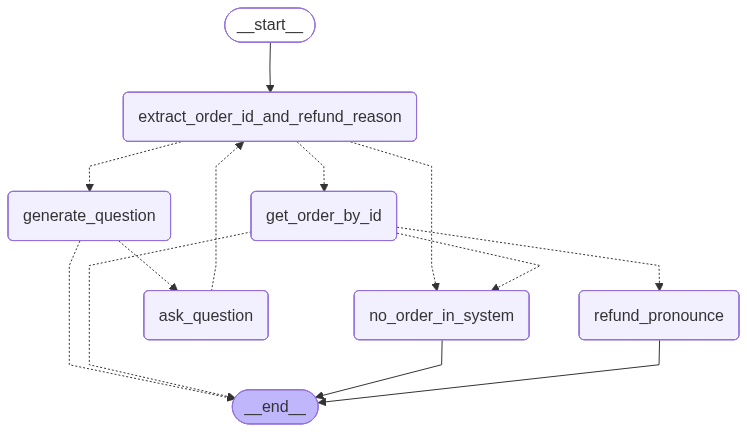

In [37]:
graph_builder = StateGraph(ChatState)

graph_builder.add_node(NODE_NAME.EXTRACT_ORDER_ID_AND_REFUND_REASON.value, extract_order_id_and_refund_reason)

graph_builder.add_node(NODE_NAME.GENERATE_QUESTION.value, generate_question)
graph_builder.add_node(NODE_NAME.GET_ORDER_BY_ID.value, get_order_by_id)
graph_builder.add_node(NODE_NAME.REFUND_PRONOUNCE.value, refund_pronounce)
graph_builder.add_node(NODE_NAME.NO_ORDER_IN_SYSTEM.value, no_order_in_system)
graph_builder.add_node(NODE_NAME.ASK_QUESTION.value, ask_question)


graph_builder.add_edge(START, NODE_NAME.EXTRACT_ORDER_ID_AND_REFUND_REASON.value)
graph_builder.add_conditional_edges(
    NODE_NAME.EXTRACT_ORDER_ID_AND_REFUND_REASON.value,
    after_extract_order_id_and_refund_reason,
    {
        NODE_NAME.GENERATE_QUESTION.value: NODE_NAME.GENERATE_QUESTION.value,
        NODE_NAME.GET_ORDER_BY_ID.value: NODE_NAME.GET_ORDER_BY_ID.value,
        NODE_NAME.NO_ORDER_IN_SYSTEM.value: NODE_NAME.NO_ORDER_IN_SYSTEM.value,
    }
)

graph_builder.add_conditional_edges(
    NODE_NAME.GENERATE_QUESTION.value,
    after_generate_question,
    {
        NODE_NAME.ASK_QUESTION.value: NODE_NAME.ASK_QUESTION.value,
        END: END,
    }
)
graph_builder.add_conditional_edges(
    NODE_NAME.ASK_QUESTION.value,
    after_ask_question,
    {
        NODE_NAME.EXTRACT_ORDER_ID_AND_REFUND_REASON.value: NODE_NAME.EXTRACT_ORDER_ID_AND_REFUND_REASON.value,
    }
)
graph_builder.add_conditional_edges(
    NODE_NAME.GET_ORDER_BY_ID.value,
    after_get_order_by_id,
    {
        NODE_NAME.REFUND_PRONOUNCE.value: NODE_NAME.REFUND_PRONOUNCE.value,
        NODE_NAME.NO_ORDER_IN_SYSTEM.value: NODE_NAME.NO_ORDER_IN_SYSTEM.value,
        END: END,
    }
)
graph_builder.add_edge(NODE_NAME.REFUND_PRONOUNCE.value, END)
graph_builder.add_edge(NODE_NAME.NO_ORDER_IN_SYSTEM.value, END)

graph=graph_builder.compile()

import IPython
IPython.display.Image(graph.get_graph().draw_mermaid_png())

In [38]:
init_state = {
    "new_message": "Tôi muốn hoàn tiền"
}

result=graph.invoke(init_state)

Start extract order_id and refund_reason from chat conversation
Start generating question
Start asking question


In [39]:
result

{'messages': [{'role': 'user', 'content': 'Tôi muốn hoàn tiền'},
  {'role': 'assistant',
   'content': 'Dạ, anh/chị vui lòng cung cấp mã đơn hàng và lý do mình muốn hoàn tiền để em có thể hỗ trợ kiểm tra và xử lý giúp mình ạ.'}],
 'question': 'Dạ, anh/chị vui lòng cung cấp mã đơn hàng và lý do mình muốn hoàn tiền để em có thể hỗ trợ kiểm tra và xử lý giúp mình ạ.',
 'new_message': 'Tôi muốn hoàn tiền',
 'order_id': None,
 'refund_reason': None,
 'need_human_approval': True,
 '__interrupt__': [Interrupt(value='Dạ, anh/chị vui lòng cung cấp mã đơn hàng và lý do mình muốn hoàn tiền để em có thể hỗ trợ kiểm tra và xử lý giúp mình ạ.', id='04e7b494e25293fdfa44a06297cb1ef3')]}

In [40]:
result["messages"][-1]["content"]

'Dạ, anh/chị vui lòng cung cấp mã đơn hàng và lý do mình muốn hoàn tiền để em có thể hỗ trợ kiểm tra và xử lý giúp mình ạ.'

In [41]:
result=graph.invoke({
    "new_message": "it13567890"
})
result["messages"][-1]["content"]




Start extract order_id and refund_reason from chat conversation
Start generating question
Start asking question


'Chào anh/chị, em đã nhận được mã đơn hàng ạ. Anh/chị vui lòng cho em biết lý do mình muốn hoàn tiền để em hỗ trợ xử lý tiếp nhé.'

In [42]:
result=graph.invoke({
    "new_message": "hàng lỗi "
})
result["messages"][-1]["content"]




Start extract order_id and refund_reason from chat conversation
Start generating question
Start asking question


'Dạ, anh/chị vui lòng cung cấp mã đơn hàng để em có thể hỗ trợ kiểm tra và xử lý yêu cầu hoàn tiền cho mình nhé.'

In [43]:
# Add checkpoint 
from langgraph.checkpoint.memory import InMemorySaver  
checkpointer = InMemorySaver()  
config =  {"configurable": {"thread_id": "2"}}
graph=graph_builder.compile(checkpointer=checkpointer)



In [44]:
result=graph.invoke({
    "new_message": "Tôi muốn hoàn tiền"
}, config=config)

Start extract order_id and refund_reason from chat conversation
Start generating question
Start asking question


In [45]:
result

{'messages': [{'role': 'user', 'content': 'Tôi muốn hoàn tiền'},
  {'role': 'assistant',
   'content': 'Dạ, anh/chị vui lòng cung cấp mã đơn hàng và lý do hoàn tiền để em có thể hỗ trợ xử lý yêu cầu này cho mình ngay ạ.'}],
 'question': 'Dạ, anh/chị vui lòng cung cấp mã đơn hàng và lý do hoàn tiền để em có thể hỗ trợ xử lý yêu cầu này cho mình ngay ạ.',
 'new_message': 'Tôi muốn hoàn tiền',
 'order_id': None,
 'refund_reason': None,
 'need_human_approval': True,
 '__interrupt__': [Interrupt(value='Dạ, anh/chị vui lòng cung cấp mã đơn hàng và lý do hoàn tiền để em có thể hỗ trợ xử lý yêu cầu này cho mình ngay ạ.', id='d7a4b6cf2fc65a253757e3b72640c4f6')]}

In [46]:
result["__interrupt__"]

[Interrupt(value='Dạ, anh/chị vui lòng cung cấp mã đơn hàng và lý do hoàn tiền để em có thể hỗ trợ xử lý yêu cầu này cho mình ngay ạ.', id='d7a4b6cf2fc65a253757e3b72640c4f6')]

In [47]:
checkpointer.get(config=config)["channel_values"]

{'new_message': 'Tôi muốn hoàn tiền',
 'order_id': None,
 'refund_reason': None,
 'messages': [{'role': 'user', 'content': 'Tôi muốn hoàn tiền'},
  {'role': 'assistant',
   'content': 'Dạ, anh/chị vui lòng cung cấp mã đơn hàng và lý do hoàn tiền để em có thể hỗ trợ xử lý yêu cầu này cho mình ngay ạ.'}],
 'need_human_approval': True,
 'question': 'Dạ, anh/chị vui lòng cung cấp mã đơn hàng và lý do hoàn tiền để em có thể hỗ trợ xử lý yêu cầu này cho mình ngay ạ.',
 'branch:to:ask_question': None}

In [48]:
from langgraph.types import interrupt, Command
result=graph.invoke(
    Command(resume="Mã qt35 nhé")
, config=config)
result["messages"][-1]["content"]











Start asking question
After asking question: Mã qt35 nhé
Start extract order_id and refund_reason from chat conversation
Start generating question
Start asking question


'Dạ, anh/chị vui lòng cho em biết lý do mình muốn hoàn tiền cho đơn hàng qt35 để em có thể hỗ trợ xử lý tiếp cho mình nhé.'

In [49]:
from langgraph.types import interrupt, Command
result=graph.invoke(
    Command(resume="hòan tiền do hàng lỗi ")
, config=config)
result["messages"][-1]["content"]











Start asking question
After asking question: hòan tiền do hàng lỗi 
Start extract order_id and refund_reason from chat conversation
Start getting order by id
Start no order in system


'Hiện tại hệ thống chưa tìm thấy thông tin đơn hàng của anh/chị. Anh chị vui lòng kiểm tra lại thông tin mã đơn hàng.'

In [50]:
result

{'messages': [{'role': 'user', 'content': 'Tôi muốn hoàn tiền'},
  {'role': 'assistant',
   'content': 'Dạ, anh/chị vui lòng cung cấp mã đơn hàng và lý do hoàn tiền để em có thể hỗ trợ xử lý yêu cầu này cho mình ngay ạ.'},
  {'role': 'user', 'content': 'Mã qt35 nhé'},
  {'role': 'user', 'content': 'Tôi muốn hoàn tiền'},
  {'role': 'assistant',
   'content': 'Dạ, anh/chị vui lòng cho em biết lý do mình muốn hoàn tiền cho đơn hàng qt35 để em có thể hỗ trợ xử lý tiếp cho mình nhé.'},
  {'role': 'user', 'content': 'hòan tiền do hàng lỗi '},
  {'role': 'user', 'content': 'Tôi muốn hoàn tiền'},
  {'role': 'assistant',
   'content': 'Hiện tại hệ thống chưa tìm thấy thông tin đơn hàng của anh/chị. Anh chị vui lòng kiểm tra lại thông tin mã đơn hàng.'}],
 'question': None,
 'new_message': 'Tôi muốn hoàn tiền',
 'order_id': 'qt35',
 'refund_reason': 'hàng lỗi',
 'need_human_approval': False}